<a href="https://colab.research.google.com/github/keeganjewell/DS4002-Project-1/blob/main/SCRIPTS/05_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genre Classification Analysis

This notebook performs the final analysis for the DS 4002 song genre classification project. It uses the final English-language song dataset to evaluate whether a song's genre can be predicted from its lyrical content using TF-IDF features and logistic regression.

## 1. Setup and Imports

In [48]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Text feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Modeling
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_SEED = 4002

## 2. Load and Validate the Final Dataset

The final dataset is checked before modeling to confirm its size, genre balance, artist balance, missing values, and duplicate records.

In [49]:
# Load the final dataset directly from GitHub

url = "https://raw.githubusercontent.com/keeganjewell/DS4002-Project-1/main/DATA/music_genre_dataset_final.csv"

df = pd.read_csv(url)

# Preview the first few rows
df.head()

,recording_id,song_title,artist,artist_id,musicbrainz_tags,target_genre,lrclib_artist,lrclib_title,lyrics,lyrics_found,language
0,86875957-15df-4f55-a730-71229fc3f9a6,Holy Water,Big & Rich,9c76170f-0d77-4aa3-b3c9-52f1ce07b9ec,"country, alternative country, contemporary cou...",Country,Big & Rich,Holy Water,Somewhere there's a stolen halo\nI used to wat...,True,en
1,9e4710b0-42d7-42d1-8cd7-6a6697f30c35,Intro,Big & Rich,9c76170f-0d77-4aa3-b3c9-52f1ce07b9ec,"country, country pop, contemporary country, co...",Country,Big & Rich,Intro,"""Intro""\nBig & Rich\n\nBecause our task at the...",True,en
2,d5d2433c-a754-4e5e-9882-a2b9d91eabbc,High Five,Big & Rich,9c76170f-0d77-4aa3-b3c9-52f1ce07b9ec,"country, country rock, country pop, contempora...",Country,Big & Rich,High Five,Run and I will run with you\nFaster than light...,True,en
3,77c25bd8-e39b-43f1-9b2f-32eff73cee63,You Never Stop Loving Somebody,Big & Rich,9c76170f-0d77-4aa3-b3c9-52f1ce07b9ec,"country, country pop, alternative country, con...",Country,Big & Rich,You Never Stop Loving Somebody,"It's complicated, when love has faded\nAnd you...",True,en
4,4db3591e-f500-457b-8a25-f91abefdb575,Love Train,Big & Rich,9c76170f-0d77-4aa3-b3c9-52f1ce07b9ec,"country, alternative country, contemporary cou...",Country,Big & Rich,Love Train,I see people gettin' mad on CNN\nWho's right? ...,True,en


In [50]:
# Validate the final dataset

print("Dataset shape:", df.shape)

print("\nGenre counts:")
print(df["target_genre"].value_counts())

print("\nUnique artists by genre:")
print(df.groupby("target_genre")["artist"].nunique())

print("\nMissing lyrics:", df["lyrics"].isna().sum())

print("Duplicate recording IDs:", df["recording_id"].duplicated().sum())

Dataset shape: (400, 11)

Genre counts:
target_genre
Country        100
Pop            100
Rock           100
Hip-Hop/Rap    100
Name: count, dtype: int64

Unique artists by genre:
target_genre
Country        20
Hip-Hop/Rap    20
Pop            20
Rock           20
Name: artist, dtype: int64

Missing lyrics: 0
Duplicate recording IDs: 0


## 3. Diagnose Country Sample Shortfall

In [51]:
# Load the larger dataset before the final artist/song trimming step

lyrics_url = "https://raw.githubusercontent.com/keeganjewell/DS4002-Project-1/main/DATA/music_genre_dataset_with_lyrics.csv"

lyrics_df = pd.read_csv(lyrics_url)

print("Rows in pre-final dataset:", len(lyrics_df))

country = lyrics_df[lyrics_df["target_genre"] == "Country"].copy()

print("Country candidate songs:", len(country))
print("Country candidate artists:", country["artist"].nunique())
print("Country songs with lyrics:", country["lyrics"].notna().sum())

Rows in pre-final dataset: 1707
Country candidate songs: 101
Country candidate artists: 15
Country songs with lyrics: 92


In [52]:
GENRE_TAGS_WIDE = {
    "Country": [
        "country",
        "country rock",
        "contemporary country",
        "alternative country",
        "outlaw country"
    ]
}

In [53]:
# Load the existing scale-check helper functions from GitHub

!wget -q https://raw.githubusercontent.com/keeganjewell/DS4002-Project-1/main/SCRIPTS/scale_check.py -O /content/scale_check.py

import sys
sys.path.append("/content")

from scale_check import probe_genre

In [54]:
# Test the broadened Country search

country_result = probe_genre(
    GENRE_TAGS_WIDE["Country"],
    "Country"
)


=== Country (tags: ['country', 'country rock', 'contemporary country', 'alternative country', 'outlaw country']) ===
  -- querying tag 'country' --
     raw recordings fetched: 500
  -- querying tag 'country rock' --
    MusicBrainz busy, waiting 5s (attempt 1/5)
     raw recordings fetched: 500
  -- querying tag 'contemporary country' --
     raw recordings fetched: 500
  -- querying tag 'alternative country' --
    MusicBrainz busy, waiting 5s (attempt 1/5)
     raw recordings fetched: 500
  -- querying tag 'outlaw country' --
     raw recordings fetched: 500
  Unique recordings across all tags: 2135
  Artists with >= 5 songs: 105
  ...of which single-artist-credit: 102
    checked popularity for 20/102 artists...
    checked popularity for 40/102 artists...
    checked popularity for 60/102 artists...
    checked popularity for 80/102 artists...
    checked popularity for 100/102 artists...
  Artists with >= 1,000 ListenBrainz listeners: 88
  --> Need 20 artists x 5 songs = 100 son

## 3. Repair Country Sample

The original final dataset contained only 65 Country songs from 13 artists, rather than the planned 100 songs from 20 artists. The Country candidate search was therefore broadened using additional MusicBrainz tags before modeling.

In [55]:
!pip -q install langdetect

In [56]:
# Load the final data-collection functions from GitHub

!wget -q https://raw.githubusercontent.com/keeganjewell/DS4002-Project-1/main/SCRIPTS/collect_dataset.py -O /content/collect_dataset.py

import sys
sys.path.append("/content")

from collect_dataset import (
    build_artist_pool,
    select_candidate_songs,
    get_lrclib_lyrics,
    detect_language,
    RANDOM_SEED,
    SONGS_PER_ARTIST,
    ARTISTS_PER_GENRE_TARGET
)

import time

In [57]:
# Build the broadened Country artist pool

country_tags = [
    "country",
    "country rock",
    "contemporary country",
    "alternative country",
    "outlaw country"
]

country_df, country_popular = build_artist_pool(
    country_tags,
    "Country"
)

print("\nEligible popular Country artists:", len(country_popular))


=== Building candidate pool: Country (tags: ['country', 'country rock', 'contemporary country', 'alternative country', 'outlaw country']) ===
    MusicBrainz busy, waiting 5s (attempt 1/5)
  'country': 500 raw recordings
  'country rock': 500 raw recordings
    MusicBrainz busy, waiting 5s (attempt 1/5)
    MusicBrainz busy, waiting 5s (attempt 1/5)
  'contemporary country': 500 raw recordings
    MusicBrainz busy, waiting 5s (attempt 1/5)
  'alternative country': 500 raw recordings
  'outlaw country': 500 raw recordings
  Unique recordings: 2135
  Artists with >=5 songs, single-credit: 102
    ListenBrainz checked 25/102
    ListenBrainz checked 50/102
    ListenBrainz checked 75/102
    ListenBrainz checked 100/102
  Artists with >=1,000 listeners: 88

Eligible popular Country artists: 88


In [58]:
# Select candidate Country songs from the eligible artist pool

country_candidates = select_candidate_songs(
    country_df,
    country_popular
)

print("Country candidate songs selected:", len(country_candidates))
print("Country candidate artists:", country_candidates["artist"].nunique())

country_candidates.head()

Country candidate songs selected: 638
Country candidate artists: 88


,recording_id,song_title,artist,artist_id,musicbrainz_tags,target_genre
0,22a26fe9-360c-4634-a3f7-d0b6e68b65f7,The Closer You Get,Alabama,7ac055fa-e357-4890-9098-010b8094a900,"country, country rock, country pop, classic co...",Country
1,525f6765-faaa-46ec-8fd4-3cd7ecd57e32,Pass It On Down,Alabama,7ac055fa-e357-4890-9098-010b8094a900,"country, country rock, country pop, contempora...",Country
2,8a8ff1ac-60e0-44e7-a8b2-36a5e3b8b945,Hillbilly Wins the Lotto Money,Alabama,7ac055fa-e357-4890-9098-010b8094a900,country rock,Country
3,d1783d87-aafe-4f89-8e4e-f4dd85aac866,Southern Drawl,Alabama,7ac055fa-e357-4890-9098-010b8094a900,country rock,Country
4,b9c2af67-9f48-4aeb-962f-be99a9ba967e,If You're Gonna Play in Texas (You Gotta Have ...,Alabama,7ac055fa-e357-4890-9098-010b8094a900,"country, country rock, country pop, contempora...",Country


> **Note:** This section documents the one-time repair of the Country sample.
> The corrected 400-song dataset is now stored in the GitHub repository,
> so these cells do not need to be rerun to reproduce the classification analysis.

In [59]:
# Fetch lyrics for the broadened Country candidate pool

country_with_lyrics = country_candidates.copy()

matched_artists = []
matched_titles = []
lyrics_list = []

for i, row in country_with_lyrics.iterrows():
    try:
        matched_artist, matched_title, lyrics = get_lrclib_lyrics(
            row["song_title"],
            row["artist"]
        )
    except Exception as e:
        print(f"Error on '{row['song_title']}': {e}")
        matched_artist, matched_title, lyrics = None, None, None

    matched_artists.append(matched_artist)
    matched_titles.append(matched_title)
    lyrics_list.append(lyrics)

    # Progress update
    if (i + 1) % 25 == 0:
        print(f"{i + 1}/{len(country_with_lyrics)} processed")

    # Save a checkpoint every 50 songs
    if (i + 1) % 50 == 0:
        checkpoint = country_with_lyrics.iloc[:i + 1].copy()
        checkpoint["lrclib_artist"] = matched_artists
        checkpoint["lrclib_title"] = matched_titles
        checkpoint["lyrics"] = lyrics_list
        checkpoint.to_csv("/content/country_lyrics_checkpoint.csv", index=False)

    time.sleep(1)

country_with_lyrics["lrclib_artist"] = matched_artists
country_with_lyrics["lrclib_title"] = matched_titles
country_with_lyrics["lyrics"] = lyrics_list
country_with_lyrics["lyrics_found"] = country_with_lyrics["lyrics"].notna()

print(
    "\nLyrics found:",
    country_with_lyrics["lyrics_found"].sum(),
    "/",
    len(country_with_lyrics)
)

25/638 processed
50/638 processed
75/638 processed
100/638 processed
125/638 processed
150/638 processed
175/638 processed
200/638 processed
225/638 processed
250/638 processed
275/638 processed
300/638 processed
325/638 processed
350/638 processed
375/638 processed
400/638 processed
425/638 processed
450/638 processed
475/638 processed


KeyboardInterrupt: 

In [60]:
# Retry songs whose lyrics were not found on the first pass

missing_idx = country_with_lyrics[
    ~country_with_lyrics["lyrics_found"]
].index

print("Retrying missing lyrics:", len(missing_idx))

for n, i in enumerate(missing_idx):
    artist = country_with_lyrics.loc[i, "artist"]
    title = country_with_lyrics.loc[i, "song_title"]

    try:
        matched_artist, matched_title, lyrics = get_lrclib_lyrics(
            title,
            artist
        )
    except Exception as e:
        print(f"Error retrying '{title}': {e}")
        matched_artist, matched_title, lyrics = None, None, None

    if lyrics is not None:
        country_with_lyrics.loc[i, "lrclib_artist"] = matched_artist
        country_with_lyrics.loc[i, "lrclib_title"] = matched_title
        country_with_lyrics.loc[i, "lyrics"] = lyrics

    if (n + 1) % 25 == 0:
        print(f"{n + 1}/{len(missing_idx)} retried")

    time.sleep(1.5)

country_with_lyrics["lyrics_found"] = country_with_lyrics["lyrics"].notna()

print(
    "\nLyrics found after retry:",
    country_with_lyrics["lyrics_found"].sum(),
    "/",
    len(country_with_lyrics)
)

KeyError: 'lyrics_found'

In [ ]:
# Detect language and keep English-language Country songs

country_with_lyrics["language"] = country_with_lyrics["lyrics"].apply(detect_language)

country_clean = country_with_lyrics[
    (country_with_lyrics["lyrics_found"]) &
    (country_with_lyrics["language"] == "en")
].copy()

print("English Country songs:", len(country_clean))

# Count usable English songs per artist
country_artist_counts = (
    country_clean.groupby("artist")
    .size()
    .sort_values(ascending=False)
)

full_country_artists = country_artist_counts[
    country_artist_counts >= SONGS_PER_ARTIST
]

print("Country artists with at least 5 usable English songs:", len(full_country_artists))

print("\nTop artist song counts:")
print(country_artist_counts.head(25))

In [ ]:
# Select the final 20 Country artists and 5 songs per artist

chosen_country_artists = pd.Series(
    full_country_artists.index
).sample(
    n=ARTISTS_PER_GENRE_TARGET,
    random_state=RANDOM_SEED
)

country_final = (
    country_clean[
        country_clean["artist"].isin(chosen_country_artists)
    ]
    .groupby("artist", group_keys=False)
    .sample(
        n=SONGS_PER_ARTIST,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

print("Final Country songs:", len(country_final))
print("Final Country artists:", country_final["artist"].nunique())

print("\nSongs per selected artist:")
print(country_final["artist"].value_counts())

In [ ]:
# Combine repaired Country sample with the existing 300 non-Country songs

non_country = df[df["target_genre"] != "Country"].copy()

final_400 = pd.concat(
    [country_final, non_country],
    ignore_index=True
)

# Validate the repaired final dataset
print("Dataset shape:", final_400.shape)

print("\nGenre counts:")
print(final_400["target_genre"].value_counts())

print("\nUnique artists by genre:")
print(final_400.groupby("target_genre")["artist"].nunique())

print("\nMissing lyrics:", final_400["lyrics"].isna().sum())
print("Duplicate recording IDs:", final_400["recording_id"].duplicated().sum())

# Check whether any artist appears under more than one genre
artist_genre_counts = final_400.groupby("artist")["target_genre"].nunique()
cross_genre_artists = artist_genre_counts[artist_genre_counts > 1]

print("\nArtists appearing in more than one genre:", len(cross_genre_artists))

if len(cross_genre_artists) > 0:
    print(cross_genre_artists)

In [ ]:
# Save the corrected balanced dataset

final_400.to_csv(
    "/content/music_genre_dataset_final.csv",
    index=False
)

print("Saved corrected final dataset.")
print("Shape:", final_400.shape)

In [ ]:
url = "https://raw.githubusercontent.com/keeganjewell/DS4002-Project-1/main/DATA/music_genre_dataset_final.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print(df["target_genre"].value_counts())

## 4. Artist-Disjoint Train/Test Split

The dataset is divided into training and testing sets by artist rather than by individual song. This prevents songs from the same artist from appearing in both sets and tests whether the classifier can generalize to previously unseen artists. Within each genre, 16 artists are assigned to the training set and 4 artists to the test set.

In [64]:
# Create an artist-disjoint 80/20 train/test split

train_parts = []
test_parts = []

for genre in sorted(df["target_genre"].unique()):

    # Get the 20 unique artists for this genre
    genre_artists = df.loc[
        df["target_genre"] == genre,
        "artist"
    ].unique()

    # Randomly choose 4 artists for the test set
    rng = np.random.default_rng(RANDOM_SEED)
    test_artists = rng.choice(
        genre_artists,
        size=4,
        replace=False
    )

    # Remaining 16 artists go into training
    train_artists = [
        artist for artist in genre_artists
        if artist not in test_artists
    ]

    train_parts.append(
        df[
            (df["target_genre"] == genre) &
            (df["artist"].isin(train_artists))
        ]
    )

    test_parts.append(
        df[
            (df["target_genre"] == genre) &
            (df["artist"].isin(test_artists))
        ]
    )

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

print("\nTraining songs by genre:")
print(train_df["target_genre"].value_counts())

print("\nTest songs by genre:")
print(test_df["target_genre"].value_counts())

# Verify no artist appears in both sets
overlap = set(train_df["artist"]) & set(test_df["artist"])

print("\nArtists appearing in both sets:", len(overlap))

Training set shape: (320, 11)
Test set shape: (80, 11)

Training songs by genre:
target_genre
Country        80
Hip-Hop/Rap    80
Pop            80
Rock           80
Name: count, dtype: int64

Test songs by genre:
target_genre
Country        20
Hip-Hop/Rap    20
Pop            20
Rock           20
Name: count, dtype: int64

Artists appearing in both sets: 0


## 5. TF-IDF Feature Extraction

Song lyrics are converted into numerical features using Term Frequency-Inverse Document Frequency (TF-IDF). The vectorizer is fit only on the training lyrics to prevent information from the test set from influencing the model.

In [63]:
# Separate lyrics and genre labels

X_train_text = train_df["lyrics"]
X_test_text = test_df["lyrics"]

y_train = train_df["target_genre"]
y_test = test_df["target_genre"]

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

# Fit only on the training lyrics
X_train = tfidf.fit_transform(X_train_text)

# Use the fitted vocabulary to transform the test lyrics
X_test = tfidf.transform(X_test_text)

print("Training feature matrix:", X_train.shape)
print("Test feature matrix:", X_test.shape)
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

Training feature matrix: (320, 4160)
Test feature matrix: (80, 4160)
Number of TF-IDF features: 4160


## 6. Logistic Regression Classification

A logistic regression classifier is trained using the TF-IDF features extracted from the training lyrics. The model then predicts the genre of songs from artists that were not included in the training set.

In [62]:
# Train the logistic regression classifier

model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_SEED
)

model.fit(X_train, y_train)

# Predict genres for the held-out test songs
y_pred = model.predict(X_test)

print("Model training complete.")
print("Number of test predictions:", len(y_pred))

Model training complete.
Number of test predictions: 80


In [61]:
url = "https://raw.githubusercontent.com/keeganjewell/DS4002-Project-1/main/DATA/music_genre_dataset_final.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print(df["target_genre"].value_counts())

Dataset shape: (400, 11)
target_genre
Country        100
Pop            100
Rock           100
Hip-Hop/Rap    100
Name: count, dtype: int64


In [65]:
# Train the logistic regression classifier

model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_SEED
)

model.fit(X_train, y_train)

# Predict genres for the held-out test songs
y_pred = model.predict(X_test)

print("Model training complete.")
print("Number of test predictions:", len(y_pred))

Model training complete.
Number of test predictions: 80


## 7. Model Evaluation

The classifier is evaluated on the held-out test set using accuracy, macro F1-score, precision, and recall. Because the test set contains an equal number of songs from each genre, these metrics provide a balanced assessment of performance across the four genre classes.

In [66]:
# Evaluate model performance

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test Accuracy: {accuracy:.3f}")
print(f"Macro F1 Score: {macro_f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.450
Macro F1 Score: 0.464

Classification Report:
              precision    recall  f1-score   support

     Country       0.30      0.45      0.36        20
 Hip-Hop/Rap       0.94      0.75      0.83        20
         Pop       0.25      0.25      0.25        20
        Rock       0.50      0.35      0.41        20

    accuracy                           0.45        80
   macro avg       0.50      0.45      0.46        80
weighted avg       0.50      0.45      0.46        80



## 8. Confusion Matrix

A confusion matrix is used to examine which genres the classifier most frequently confuses with one another.

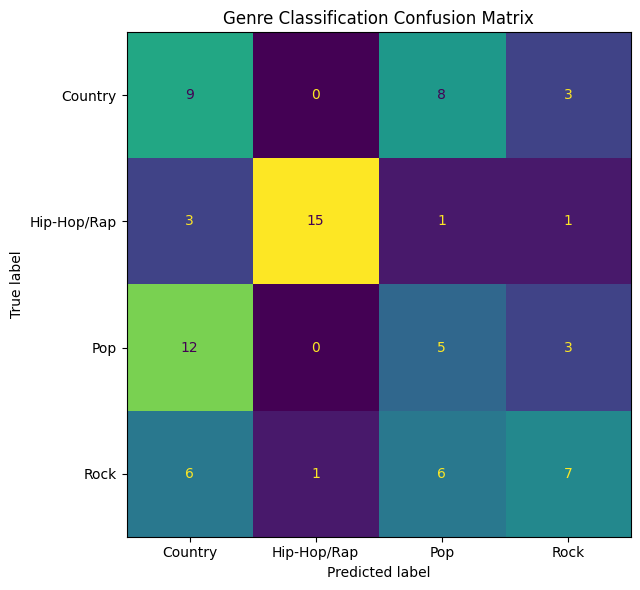

In [67]:
# Create the confusion matrix

labels = model.classes_

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title("Genre Classification Confusion Matrix")
plt.tight_layout()
plt.show()

## 9. Save Model Outputs

In [68]:
# Save classification metrics as a CSV

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

metrics_df = pd.DataFrame(report).transpose()

metrics_df.to_csv(
    "/content/classification_metrics.csv"
)

print(metrics_df)

              precision  recall  f1-score  support
Country        0.300000    0.45  0.360000    20.00
Hip-Hop/Rap    0.937500    0.75  0.833333    20.00
Pop            0.250000    0.25  0.250000    20.00
Rock           0.500000    0.35  0.411765    20.00
accuracy       0.450000    0.45  0.450000     0.45
macro avg      0.496875    0.45  0.463775    80.00
weighted avg   0.496875    0.45  0.463775    80.00


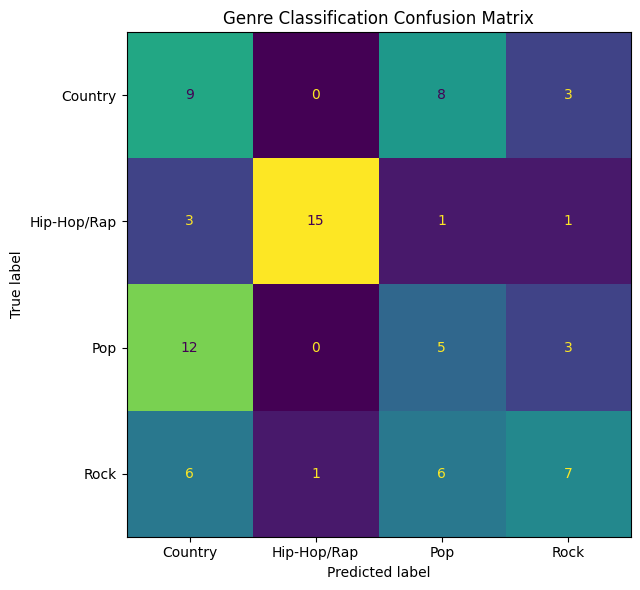

In [69]:
# Save confusion matrix as an image

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title("Genre Classification Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "/content/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Most Predictive Terms by Genre

The logistic regression coefficients are examined to identify the TF-IDF terms most strongly associated with each genre. These terms help explain which lyrical features the model uses when distinguishing among genres.

In [70]:
# Identify the terms most strongly associated with each genre

feature_names = np.array(tfidf.get_feature_names_out())

top_terms_rows = []

for class_index, genre in enumerate(model.classes_):

    # Get coefficients for this genre
    coefficients = model.coef_[class_index]

    # Find the 15 terms with the largest positive coefficients
    top_indices = np.argsort(coefficients)[-15:][::-1]

    print(f"\nTop terms for {genre}:")

    for rank, index in enumerate(top_indices, start=1):
        term = feature_names[index]
        coefficient = coefficients[index]

        print(f"{rank:2}. {term:<25} {coefficient:.3f}")

        top_terms_rows.append({
            "genre": genre,
            "rank": rank,
            "term": term,
            "coefficient": coefficient
        })

# Save results as a table
top_terms_df = pd.DataFrame(top_terms_rows)

top_terms_df.to_csv(
    "/content/top_tfidf_terms_by_genre.csv",
    index=False
)


Top terms for Country:
 1. old                       0.772
 2. loving                    0.701
 3. country                   0.639
 4. stands                    0.577
 5. left                      0.543
 6. hold                      0.523
 7. ve got                    0.503
 8. turn                      0.498
 9. talk                      0.487
10. alright                   0.452
11. outlaw                    0.447
12. business                  0.445
13. god                       0.434
14. heart                     0.424
15. loves                     0.404

Top terms for Hip-Hop/Rap:
 1. nigga                     1.486
 2. uh                        1.133
 3. em                        1.099
 4. like                      1.092
 5. niggas                    1.007
 6. shit                      0.991
 7. ass                       0.967
 8. got                       0.937
 9. fuck                      0.894
10. ya                        0.705
11. man                       0.703
12. yo      

## 11. Cross-Validation and Regularization Tuning

Logistic regression regularization strength is tuned using cross-validation on the training data only. Cross-validation folds are grouped by artist so that songs from the same artist do not appear in both the training and validation portions of a fold. Macro F1-score is used to select the best regularization parameter.

In [71]:
# Import tools for group-aware cross-validation and model tuning

from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline

# Build a pipeline so TF-IDF is fit separately within each CV fold
pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2
        )
    ),
    (
        "logreg",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_SEED
        )
    )
])

# Test several regularization strengths
param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10, 100]
}

# Keep artists grouped during cross-validation
cv = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_SEED
)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

# Fit using training lyrics only
grid_search.fit(
    train_df["lyrics"],
    train_df["target_genre"],
    groups=train_df["artist"]
)

print("Best C:", grid_search.best_params_["logreg__C"])
print("Best cross-validation Macro F1:", round(grid_search.best_score_, 3))

Best C: 10
Best cross-validation Macro F1: 0.472


## 12. Final Tuned Model Evaluation

The best-performing regularization parameter identified through artist-grouped cross-validation is used to evaluate the final model on the held-out test set.

In [72]:
# Use the best model selected during cross-validation
final_model = grid_search.best_estimator_

# Predict genres for the untouched held-out test set
final_pred = final_model.predict(test_df["lyrics"])

# Calculate final performance metrics
final_accuracy = accuracy_score(
    test_df["target_genre"],
    final_pred
)

final_macro_f1 = f1_score(
    test_df["target_genre"],
    final_pred,
    average="macro"
)

print(f"Final Test Accuracy: {final_accuracy:.3f}")
print(f"Final Macro F1 Score: {final_macro_f1:.3f}")

print("\nFinal Classification Report:")
print(
    classification_report(
        test_df["target_genre"],
        final_pred
    )
)

Final Test Accuracy: 0.438
Final Macro F1 Score: 0.456

Final Classification Report:
              precision    recall  f1-score   support

     Country       0.30      0.45      0.36        20
 Hip-Hop/Rap       0.93      0.65      0.76        20
         Pop       0.24      0.25      0.24        20
        Rock       0.53      0.40      0.46        20

    accuracy                           0.44        80
   macro avg       0.50      0.44      0.46        80
weighted avg       0.50      0.44      0.46        80



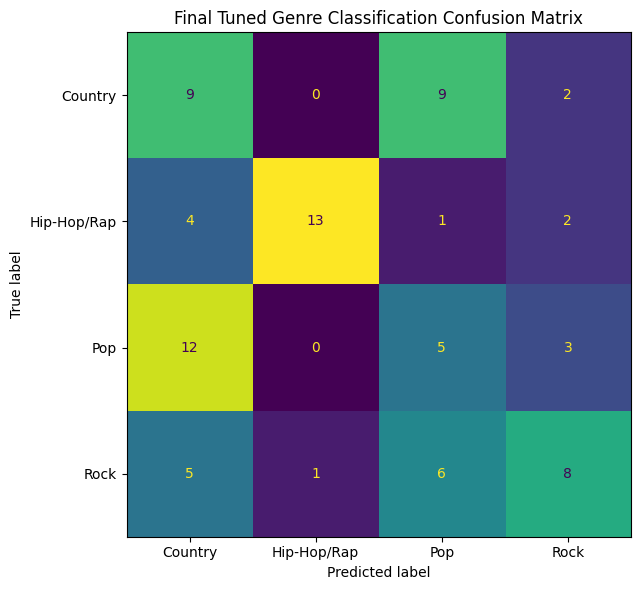

In [73]:
# Confusion matrix for the final tuned model

final_labels = final_model.named_steps["logreg"].classes_

final_cm = confusion_matrix(
    test_df["target_genre"],
    final_pred,
    labels=final_labels
)

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=final_labels
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title("Final Tuned Genre Classification Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "/content/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
# Save FINAL tuned classification metrics

final_report = classification_report(
    test_df["target_genre"],
    final_pred,
    output_dict=True
)

final_metrics_df = pd.DataFrame(final_report).transpose()

final_metrics_df.to_csv(
    "/content/classification_metrics.csv"
)

print(final_metrics_df)

              precision  recall  f1-score  support
Country        0.300000  0.4500  0.360000  20.0000
Hip-Hop/Rap    0.928571  0.6500  0.764706  20.0000
Pop            0.238095  0.2500  0.243902  20.0000
Rock           0.533333  0.4000  0.457143  20.0000
accuracy       0.437500  0.4375  0.437500   0.4375
macro avg      0.500000  0.4375  0.456438  80.0000
weighted avg   0.500000  0.4375  0.456438  80.0000


In [75]:
# Extract TF-IDF terms and coefficients from the FINAL tuned model

final_tfidf = final_model.named_steps["tfidf"]
final_logreg = final_model.named_steps["logreg"]

feature_names = np.array(
    final_tfidf.get_feature_names_out()
)

top_terms_rows = []

for class_index, genre in enumerate(final_logreg.classes_):

    coefficients = final_logreg.coef_[class_index]

    top_indices = np.argsort(
        coefficients
    )[-15:][::-1]

    print(f"\nTop terms for {genre}:")

    for rank, index in enumerate(top_indices, start=1):

        term = feature_names[index]
        coefficient = coefficients[index]

        print(
            f"{rank:2}. {term:<25} {coefficient:.3f}"
        )

        top_terms_rows.append({
            "genre": genre,
            "rank": rank,
            "term": term,
            "coefficient": coefficient
        })

final_top_terms_df = pd.DataFrame(top_terms_rows)

final_top_terms_df.to_csv(
    "/content/top_tfidf_terms_by_genre.csv",
    index=False
)


Top terms for Country:
 1. old                       2.010
 2. stands                    1.918
 3. loving                    1.772
 4. talk                      1.703
 5. country                   1.626
 6. flesh blood               1.564
 7. left                      1.543
 8. hold                      1.523
 9. business                  1.476
10. moved                     1.416
11. ve got                    1.401
12. turn                      1.368
13. god                       1.365
14. loves                     1.316
15. guns                      1.308

Top terms for Hip-Hop/Rap:
 1. nigga                     3.211
 2. uh                        2.728
 3. em                        2.568
 4. like                      2.472
 5. niggas                    2.173
 6. ass                       2.059
 7. shit                      2.052
 8. fuck                      1.963
 9. oh oh                     1.880
10. got                       1.867
11. power                     1.768
12. soul    